In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
n = 10


def cost_function(points: tuple):
    total_cost = 0
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            total_cost += np.sqrt((points[i][0] - points[j][0]) ** 2 + (points[i][1] - points[j][1]) ** 2)
    return total_cost

def generate_points(n):
    x = np.random.uniform(-10, 10, n)
    y = np.random.uniform(-10, 10, n)
    points = tuple(zip(x, y))
    return points

def proposal(points):
    # swap random points
    indices_to_swap = np.random.choice(len(points), 2, replace=False)
    i, j = indices_to_swap
    point_1_swap = points[i]
    point_2_swap = points[j]
    x, y = zip(*points)
    x = list(x)
    y = list(y)
    x[i], x[j] = point_2_swap[0], point_1_swap[0]
    y[i], y[j] = point_2_swap[1], point_1_swap[1]
    return tuple(x), tuple(y)


def cooling_scheme(k):
    return 1 / np.sqrt(1+k)

def simulate_annealing(n, iterations):
    points = generate_points(n)
    best_points = points
    best_cost = cost_function(points)
    for k in range(iterations):
        new_points = proposal(points)
        new_cost = cost_function(new_points)
        if new_cost < best_cost:
            best_cost = new_cost
            best_points = new_points
        else:
            T = cooling_scheme(k)
            acceptance_prob = np.exp((best_cost - new_cost) / T)
            if np.random.rand() < acceptance_prob:
                points = new_points
    return best_points, best_cost

best_points, best_cost = simulate_annealing(n, 1000)
print("Best points:", best_points)
print("Best cost:", best_cost)  



ValueError: too many values to unpack (expected 2)

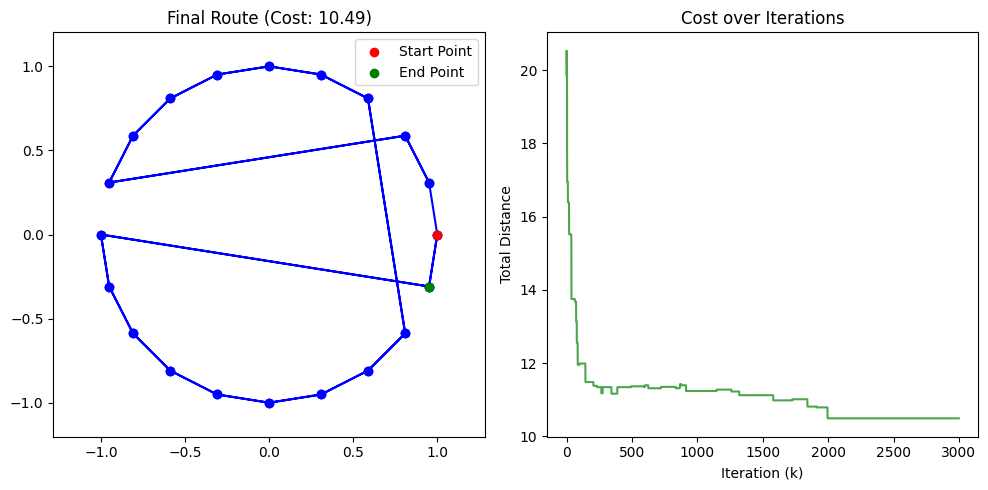

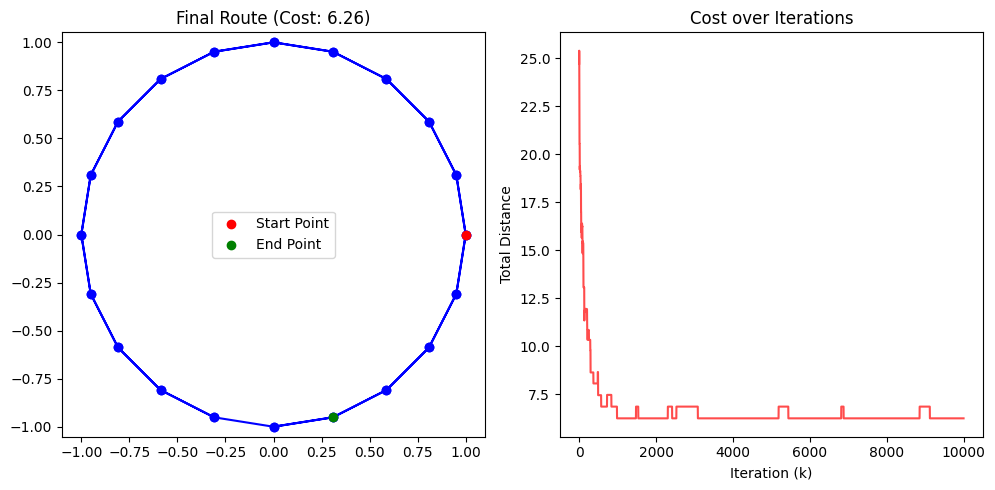

In [77]:
np.random.seed(42)
# --- 1. Objective Function ---
def total_distance(route, points):
    """Calculates the total Euclidean distance of the route."""
    dist = 0.0
    n = len(route)
    for i in range(n):
        p1 = points[route[i]]
        p2 = points[route[(i + 1) % n]] # Wrap around to the start
        dist += np.linalg.norm(p1 - p2)
    return dist

# --- 2. Simulated Annealing Algorithm ---
def simulated_annealing_tsp(points, num_iterations=3000, cooling_scheme = "sqrt"):
    n = len(points)
    
    # Initialize with a random route
    current_route = np.arange(n)
    np.random.shuffle(current_route)
    current_cost = total_distance(current_route, points)
    
    # Keep track of the best route found
    best_route = current_route.copy()
    best_cost = current_cost
    
    cost_history = np.zeros(num_iterations)
    
    for k in range(num_iterations +1):
        # Apply cooling scheme (you can swap this to 1 / np.log(2 + k))
        if cooling_scheme == "sqrt":
            T_k = 1.0 / np.sqrt(1 + k) 
        
        elif cooling_scheme == "log":
            T_k = 1.0 / np.log(2 + k)
            
        # Propose candidate by swapping two random points
        i, j = np.random.choice(n, 2, replace=False)
        candidate_route = current_route.copy()
        candidate_route[i], candidate_route[j] = candidate_route[j], candidate_route[i]
        
        candidate_cost = total_distance(candidate_route, points)
        
        # Determine whether to accept the worse proposal
        if candidate_cost <= current_cost:
            accept = True
        else:
            prob = np.exp(-(candidate_cost - current_cost) / T_k)
            accept = np.random.rand() < prob
            
        if accept:
            current_route = candidate_route
            current_cost = candidate_cost
            # Update global best if necessary
            if current_cost < best_cost:
                best_route = current_route.copy()
                best_cost = current_cost
                
        cost_history[k-1] = current_cost
        
    return best_route, best_cost, cost_history

np.random.seed(42)
n_points = 20

# Generate points on a circle and shuffle them to start with a messy route
angles = np.linspace(0, 2 * np.pi, n_points, endpoint=False)
np.random.shuffle(angles)
circle_points = np.column_stack((np.cos(angles), np.sin(angles)))

# Run the simulation
best_route_sqrt, best_cost_sqrt, cost_history_sqrt = simulated_annealing_tsp(circle_points, num_iterations=3000, cooling_scheme="sqrt")

# --- 4. Plotting the Result ---
plt.figure(figsize=(10, 5))

# Plot 1: The resulting route
plt.subplot(1, 2, 1)
ordered_points = circle_points[best_route_sqrt]
# Append the first point to close the loop for the plot
ordered_points = np.vstack((ordered_points, ordered_points)) 
plt.plot(ordered_points[:, 0], ordered_points[:, 1], marker='o', linestyle='-', color='b')
# show first and final points
plt.scatter(circle_points[0, 0], circle_points[0, 1], color='r', label='Start Point', zorder=5)
plt.scatter(ordered_points[-2, 0], ordered_points[-2, 1], color='g', label='End Point', zorder=5)
plt.legend()
plt.title(f"Final Route (Cost: {best_cost:.2f})")
plt.axis('equal')

# Plot 2: Cost over time to see the algorithm learning
plt.subplot(1, 2, 2)
plt.plot(cost_history_sqrt, color='g', alpha=0.7)
plt.title("Cost over Iterations")
plt.xlabel("Iteration (k)")
plt.ylabel("Total Distance")

plt.tight_layout()
plt.show()

np.random.seed(42)
n_points = 20
# Generate points on a circle and shuffle them to start with a messy route
angles = np.linspace(0, 2 * np.pi, n_points, endpoint=False)
np.random.shuffle(angles)
circle_points = np.column_stack((np.cos(angles), np.sin(angles)))
best_route_log, best_cost_log, cost_history_log = simulated_annealing_tsp(circle_points, num_iterations=10000, cooling_scheme="log")
plt.figure(figsize=(10, 5))

# Plot 1: The resulting route
plt.subplot(1, 2, 1)
ordered_points = circle_points[best_route_log]
# Append the first point to close the loop for the plot
ordered_points = np.vstack((ordered_points, ordered_points)) 
plt.plot(ordered_points[:, 0], ordered_points[:, 1], marker='o', linestyle='-', color='b')
# show first and final points
plt.scatter(circle_points[0, 0], circle_points[0, 1], color='r', label='Start Point', zorder=5)
plt.scatter(ordered_points[-2, 0], ordered_points[-2, 1], color='g', label='End Point', zorder=5)
plt.legend()
plt.title(f"Final Route (Cost: {best_cost_log:.2f})")
plt.axis('equal')

# Plot 2: Cost over time to see the algorithm learning
plt.subplot(1, 2, 2)
plt.plot(cost_history_log, color='r', alpha=0.7)
plt.title("Cost over Iterations")
plt.xlabel("Iteration (k)")
plt.ylabel("Total Distance")

plt.tight_layout()
plt.show()


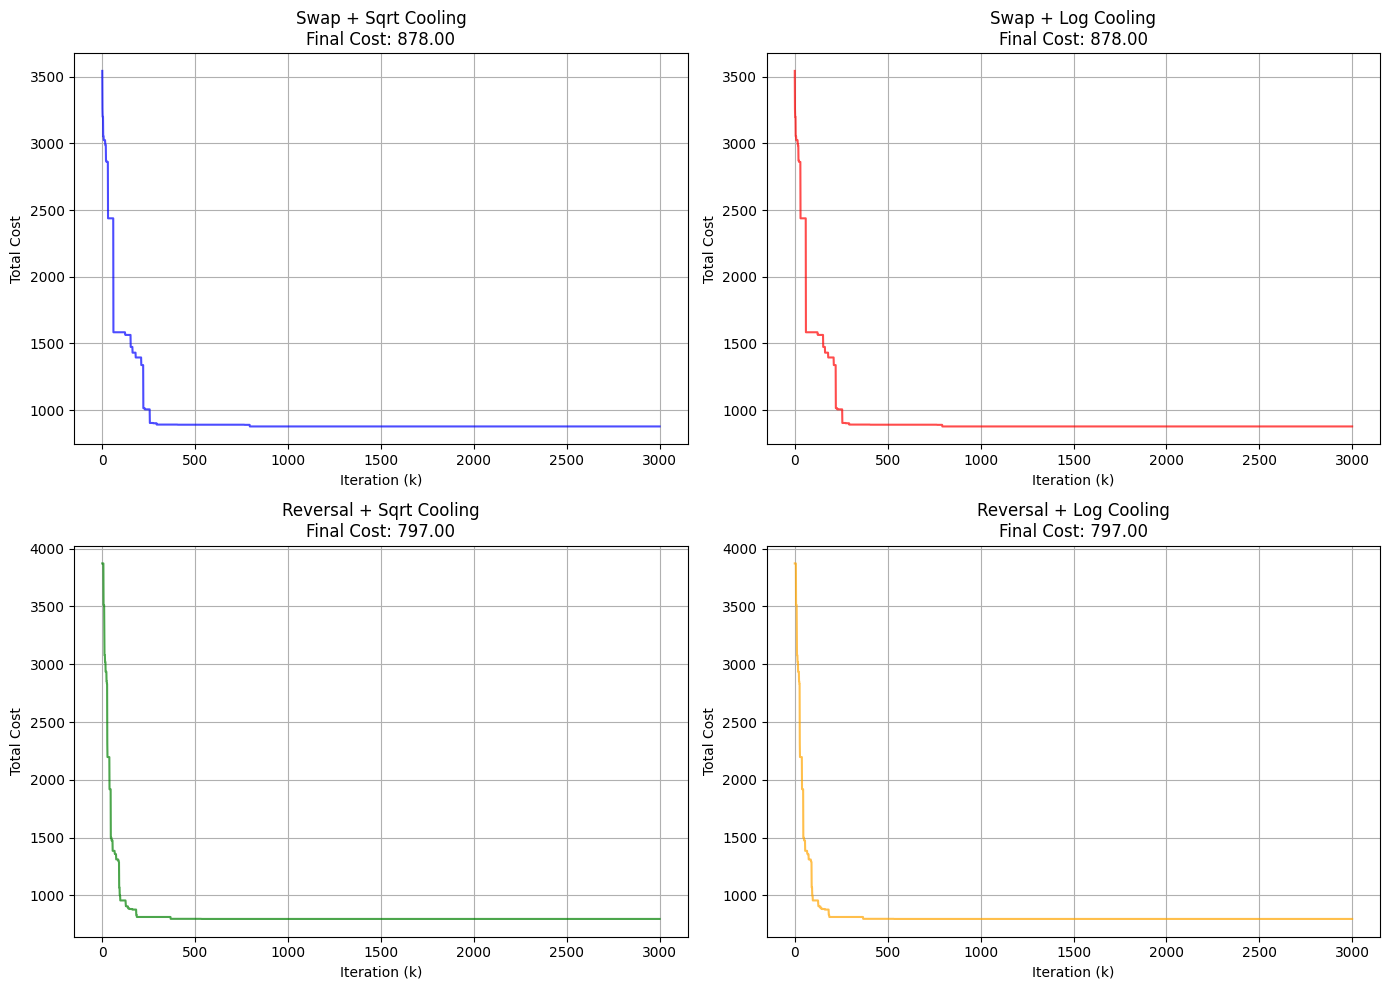

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Load Data ---
df = pd.read_csv('cost.csv', header=None)
cost_matrix = df.values
city_ids = df.index.values

# --- 2. Objective Function ---
def total_distance(route, cost_matrix):
    """Calculates the total cost of the route using the cost matrix."""
    dist = 0.0
    n = len(route)
    for i in range(n):
        dist += cost_matrix[route[i], route[(i + 1) % n]]
    return dist

# --- 3. Simulated Annealing Algorithm ---
def simulated_annealing_tsp(cost_matrix, num_iterations=3000, cooling_scheme='sqrt', proposal_method='swap', T0=100.0):
    n = cost_matrix.shape[0]
    
    current_route = np.arange(n)
    np.random.shuffle(current_route)
    current_cost = total_distance(current_route, cost_matrix)
    
    best_route = current_route.copy()
    best_cost = current_cost
    
    cost_history = np.zeros(num_iterations)
    
    for k in range(1, num_iterations + 1):
        # Cooling scheme selection
        if cooling_scheme == 'sqrt':
            T_k = T0 / np.sqrt(1 + k) 
        elif cooling_scheme == 'log':
            T_k = T0 / np.log(2 + k)
        else:
            raise ValueError("Invalid cooling scheme. Use 'sqrt' or 'log'.")
        
        # Create a fresh copy of the route for the proposal
        candidate_route = current_route.copy()
        
        # Apply the chosen proposal method cleanly
        if proposal_method == 'swap':
            i, j = np.random.choice(n, 2, replace=False)
            candidate_route[i], candidate_route[j] = candidate_route[j], candidate_route[i]
            
        elif proposal_method == 'reversal':
            i, j = np.random.choice(n, 2, replace=False)
            # Ensure the start index is smaller than the end index for python slicing
            start, end = min(i, j), max(i, j) 
            candidate_route[start:end+1] = candidate_route[start:end+1][::-1]
        else:
            raise ValueError("Invalid proposal method. Use 'swap' or 'reversal'.")
            
        candidate_cost = total_distance(candidate_route, cost_matrix)

        # Acceptance Rule (Unified for both methods)
        if candidate_cost <= current_cost:
            accept = True
        else:
            prob = np.exp(-(candidate_cost - current_cost) / T_k)
            accept = np.random.rand() < prob
            
        if accept:
            current_route = candidate_route
            current_cost = candidate_cost
            
            # Update global best if necessary
            if current_cost < best_cost:
                best_route = current_route.copy()
                best_cost = current_cost
                
        cost_history[k-1] = current_cost
        
    return best_route, best_cost, cost_history

# --- 4. Execution ---
# Adjust this based on your CSV data scale
STARTING_TEMP = 1.0 
ITERATIONS = 3000

# 1. Swap + Sqrt
np.random.seed(42)
route_swap_sqrt, cost_swap_sqrt, hist_swap_sqrt = simulated_annealing_tsp(
    cost_matrix, num_iterations=ITERATIONS, cooling_scheme='sqrt', proposal_method='swap', T0=STARTING_TEMP)

# 2. Swap + Log
np.random.seed(42)
route_swap_log, cost_swap_log, hist_swap_log = simulated_annealing_tsp(
    cost_matrix, num_iterations=ITERATIONS, cooling_scheme='log', proposal_method='swap', T0=STARTING_TEMP)

# 3. Reversal + Sqrt
np.random.seed(42)
route_rev_sqrt, cost_rev_sqrt, hist_rev_sqrt = simulated_annealing_tsp(
    cost_matrix, num_iterations=ITERATIONS, cooling_scheme='sqrt', proposal_method='reversal', T0=STARTING_TEMP)

# 4. Reversal + Log
np.random.seed(42)
route_rev_log, cost_rev_log, hist_rev_log = simulated_annealing_tsp(
    cost_matrix, num_iterations=ITERATIONS, cooling_scheme='log', proposal_method='reversal', T0=STARTING_TEMP)


# --- 5. Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1: Swap + Sqrt
axes[0, 0].plot(hist_swap_sqrt, color='b', alpha=0.7)
axes[0, 0].set_title(f"Swap + Sqrt Cooling\nFinal Cost: {cost_swap_sqrt:.2f}")
axes[0, 0].set_xlabel("Iteration (k)")
axes[0, 0].set_ylabel("Total Cost")
axes[0, 0].grid(True)

# Subplot 2: Swap + Log
axes[0, 1].plot(hist_swap_log, color='r', alpha=0.7)
axes[0, 1].set_title(f"Swap + Log Cooling\nFinal Cost: {cost_swap_log:.2f}")
axes[0, 1].set_xlabel("Iteration (k)")
axes[0, 1].set_ylabel("Total Cost")
axes[0, 1].grid(True)

# Subplot 3: Reversal + Sqrt
axes[1, 0].plot(hist_rev_sqrt, color='g', alpha=0.7)
axes[1, 0].set_title(f"Reversal + Sqrt Cooling\nFinal Cost: {cost_rev_sqrt:.2f}")
axes[1, 0].set_xlabel("Iteration (k)")
axes[1, 0].set_ylabel("Total Cost")
axes[1, 0].grid(True)

# Subplot 4: Reversal + Log
axes[1, 1].plot(hist_rev_log, color='orange', alpha=0.7)
axes[1, 1].set_title(f"Reversal + Log Cooling\nFinal Cost: {cost_rev_log:.2f}")
axes[1, 1].set_xlabel("Iteration (k)")
axes[1, 1].set_ylabel("Total Cost")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

Ex 7

Bootstrap Estimate of probability p: 0.7650


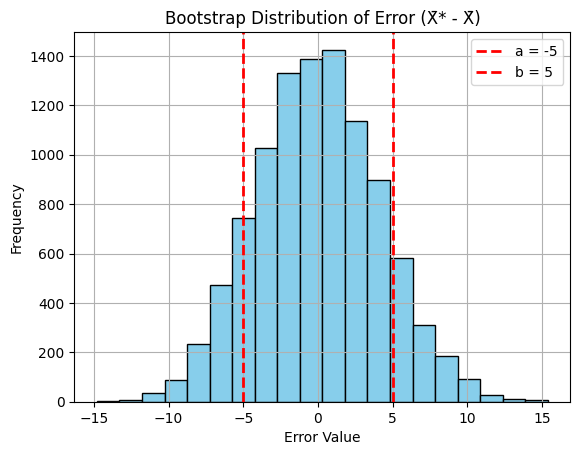

In [116]:
import numpy as np
import matplotlib.pyplot as plt

xi = [56, 101, 78, 67, 93, 87, 64, 72, 80, 69]
n = len(xi)

# Constants for the interval (a < b)
a = -5 
b = 5

np.random.seed(42)
bootstrap_samples = 10000

# 1. Calculate the original sample mean (this replaces the unknown mu)
original_mean = np.mean(xi)

# Array to store the errors/differences: (X_bar* - X_bar)
bootstrap_differences = np.zeros(bootstrap_samples)

for i in range(bootstrap_samples):
    # Draw the bootstrap sample
    sample = np.random.choice(xi, size=n, replace=True)
    
    # Calculate the bootstrap sample mean
    bootstrap_mean = np.mean(sample)
    
    # Calculate and store the difference
    bootstrap_differences[i] = bootstrap_mean - original_mean

# 2. Calculate the probability p
# Find how many differences fall strictly between a and b
successes = (bootstrap_differences > a) & (bootstrap_differences < b)

# The mean of this boolean array gives the proportion (our probability p)
estimator_p = np.mean(successes)

print(f"Bootstrap Estimate of probability p: {estimator_p:.4f}")

# 3. Plot the results
plt.hist(bootstrap_differences, bins=20, color='skyblue', edgecolor='black')

# Add vertical lines to show the boundaries a and b
plt.axvline(a, color='red', linestyle='dashed', linewidth=2, label=f'a = {a}')
plt.axvline(b, color='red', linestyle='dashed', linewidth=2, label=f'b = {b}')

plt.title("Bootstrap Distribution of Error (X̄* - X̄)")
plt.xlabel("Error Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.savefig("bootstrap_error_distribution.png")
plt.show()

ex 15

Simulated Bootstrap Estimate of Var(S^2): 59.1453


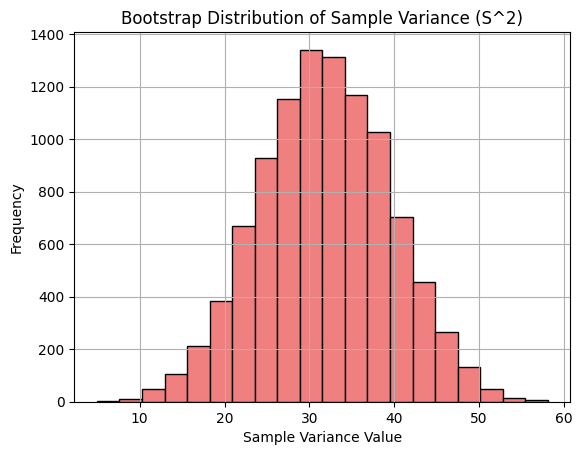

In [122]:
import numpy as np

# Original data
data = np.array([5, 4, 9, 6, 21, 17, 11, 20, 7, 10, 21, 15, 13, 16, 8])
n = len(data)
B = 10000

np.random.seed(42)

# Generate a matrix of 100,000 rows and 15 columns all at once
bootstrap_samples = np.random.choice(data, size=(B, n), replace=True)

# Calculate the variance across the rows (axis=1)
bootstrap_variances = np.var(bootstrap_samples, axis=1, ddof=1)

# Calculate the final variance of the bootstrap estimates
var_s2_boot = np.var(bootstrap_variances, ddof=1)

print(f"Simulated Bootstrap Estimate of Var(S^2): {var_s2_boot:.4f}")

plt.hist(bootstrap_variances, bins=20, color='lightcoral', edgecolor='black')
plt.title("Bootstrap Distribution of Sample Variance (S^2)")
plt.xlabel("Sample Variance Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig("bootstrap_variance_distribution.png")

ex 7 part 3

In [124]:
import numpy as np

def analyze_pareto_bootstrap(n=200, shape=1.05, scale=1.0, replicates=100):
    # Generate Pareto distributed observations
    # Numpy generates Pareto type II, so we shift it to match standard Pareto type I
    data = (np.random.pareto(shape, n) + 1) * scale

    # 1. Compute sample mean and sample median
    sample_mean = np.mean(data)
    sample_median = np.median(data)

    # Initialize arrays to store bootstrap estimates
    boot_means = np.zeros(replicates)
    boot_medians = np.zeros(replicates)

    # Generate bootstrap replicates
    for i in range(replicates):
        # Sample with replacement
        boot_sample = np.random.choice(data, size=n, replace=True)
        boot_means[i] = np.mean(boot_sample)
        boot_medians[i] = np.median(boot_sample)

    # 2 & 3. Estimate variances using the bootstrap method
    # ddof=1 is used for an unbiased sample variance estimate
    var_mean = np.var(boot_means, ddof=1)
    var_median = np.var(boot_medians, ddof=1)

    # Display results
    print(f"--- Original Sample Statistics (n={n}) ---")
    print(f"Sample Mean:   {sample_mean:.4f}")
    print(f"Sample Median: {sample_median:.4f}\n")
    
    print(f"--- Bootstrap Variance Estimates (k={replicates}) ---")
    print(f"Variance of the Mean:   {var_mean:.4f}")
    print(f"Variance of the Median: {var_median:.4f}")

# Execute the simulation
np.random.seed(42) # Set seed for reproducibility
analyze_pareto_bootstrap()

--- Original Sample Statistics (n=200) ---
Sample Mean:   4.2260
Sample Median: 1.9150

--- Bootstrap Variance Estimates (k=100) ---
Variance of the Mean:   0.2733
Variance of the Median: 0.0298
